# Notebook 4 — Evaluation
Runs the full evaluation pipeline: classifies all labeled images,
computes metrics, and renders all plots inline.

In [1]:
import sys
sys.path.insert(0, '..')

import csv
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from models.clip_classifier import ChestXrayClassifier
from evaluation.metrics import compute_metrics, format_report

print('Imports OK')

Imports OK


## 1. Load classifier and eval data

In [2]:
classifier = ChestXrayClassifier()

eval_dir = Path('../data/eval')
with open(eval_dir / 'labels.csv', encoding='utf-8') as f:
    samples = list(csv.DictReader(f))

print(f'Eval set: {len(samples)} images')
for s in samples:
    print(f'  {s["filename"]:<35} {s["label"]}')

Loading BiomedCLIP on cpu...


BiomedCLIP loaded.


Eval set: 7 images
  eval_normal_01.jpg                  no finding
  eval_pneumonia_01.jpg               pneumonia
  eval_pneumothorax_01.jpg            pneumothorax
  eval_atelectasis_01.jpg             atelectasis
  eval_pleural_effusion_01.jpg        pleural effusion
  eval_normal_02.png                  no finding
  eval_cardiomegaly_01.jpg            cardiomegaly


## 2. Run classification

In [3]:
results = []
for sample in samples:
    img_path = eval_dir / sample['filename']
    image = Image.open(img_path).convert('RGB')
    r = classifier.classify(image)
    correct = r['top_condition'] == sample['label']
    results.append({
        'filename'        : sample['filename'],
        'true_label'      : sample['label'],
        'predicted_label' : r['top_condition'],
        'top_score'       : r['top_score'],
        'all_scores'      : r['scores'],
        'low_confidence'  : r['low_confidence'],
        'correct'         : correct,
        'image'           : image,
    })
    mark = '✓' if correct else '✗'
    print(f'{mark}  {sample["label"]:<22} → {r["top_condition"]:<22} ({r["top_score"]:.1%})')

✓  no finding             → no finding             (100.0%)
✗  pneumonia              → pleural effusion       (99.7%)


✓  pneumothorax           → pneumothorax           (89.8%)


✓  atelectasis            → atelectasis            (89.1%)
✗  pleural effusion       → pneumothorax           (76.8%)


✓  no finding             → no finding             (96.2%)


✓  cardiomegaly           → cardiomegaly           (95.4%)


## 3. Metrics

In [4]:
metrics = compute_metrics(results)
print(format_report(metrics))

EVALUATION REPORT
Total images evaluated : 7
Top-1 Accuracy         : 71.4%
Top-2 Accuracy         : 71.4%
Macro Precision        : 58.3%
Macro Recall           : 66.7%
Macro F1               : 61.1%
Low-confidence flags   : 0/7
Mean conf (correct)    : 94.1%
Mean conf (incorrect)  : 88.2%

Per-class breakdown:
  Condition                Prec    Rec     F1  Support
  ------------------------------------------------------
  pneumonia                0.0%   0.0%   0.0%        1
  pleural effusion         0.0%   0.0%   0.0%        1
  cardiomegaly           100.0% 100.0% 100.0%        1
  atelectasis            100.0% 100.0% 100.0%        1
  pneumothorax            50.0% 100.0%  66.7%        1
  no finding             100.0% 100.0% 100.0%        2

Confusion matrix (rows=true, cols=predicted):
    pneumo   pleura   cardio   atelec   pneumo   no fin
  pneumo         0        1        0        0        0        0
  pleura         0        0        0        0        1        0
  cardio      

## 4. Confusion matrix

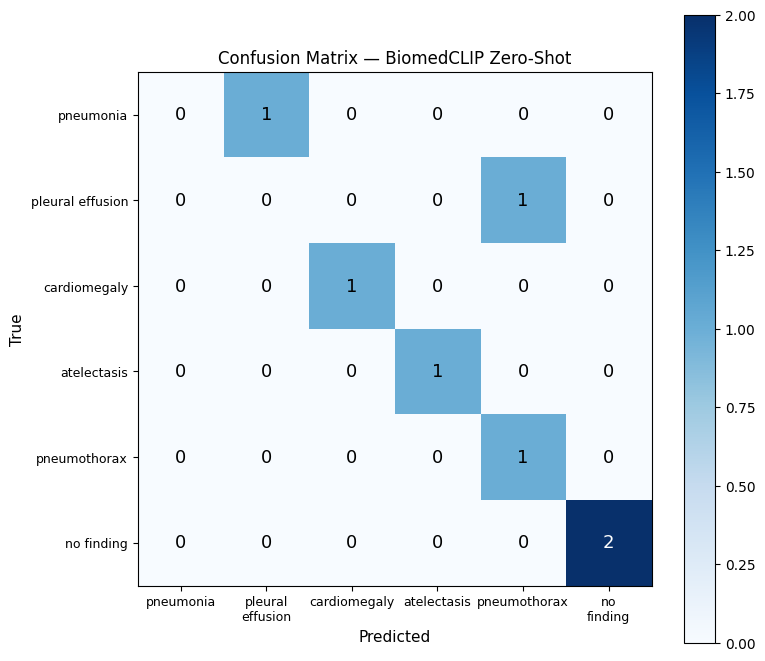

In [5]:
matrix = metrics['confusion_matrix']
conditions = metrics['conditions']

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matrix, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(conditions)))
ax.set_yticks(range(len(conditions)))
ax.set_xticklabels([c.replace(' ', '\n') for c in conditions], fontsize=9)
ax.set_yticklabels(conditions, fontsize=9)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Confusion Matrix — BiomedCLIP Zero-Shot', fontsize=12)
thresh = matrix.max() / 2.0
for i in range(len(conditions)):
    for j in range(len(conditions)):
        val = matrix[i, j]
        ax.text(j, i, str(val), ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Per-class Precision / Recall / F1

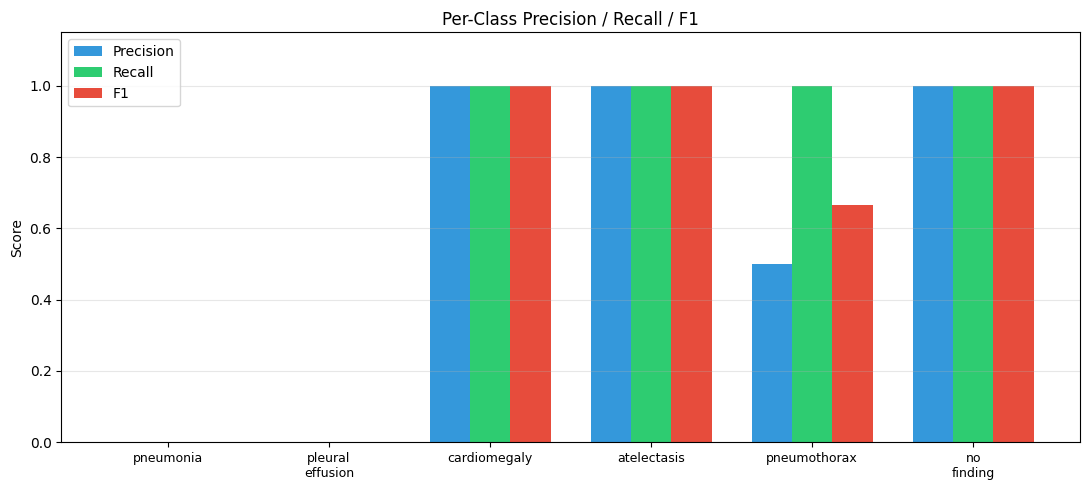

In [6]:
pc = metrics['per_class']
conds = list(pc.keys())
x = np.arange(len(conds))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, [pc[c]['precision'] for c in conds], w, label='Precision', color='#3498db')
ax.bar(x,     [pc[c]['recall']    for c in conds], w, label='Recall',    color='#2ecc71')
ax.bar(x + w, [pc[c]['f1']        for c in conds], w, label='F1',        color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in conds], fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Prediction grid (image thumbnails)

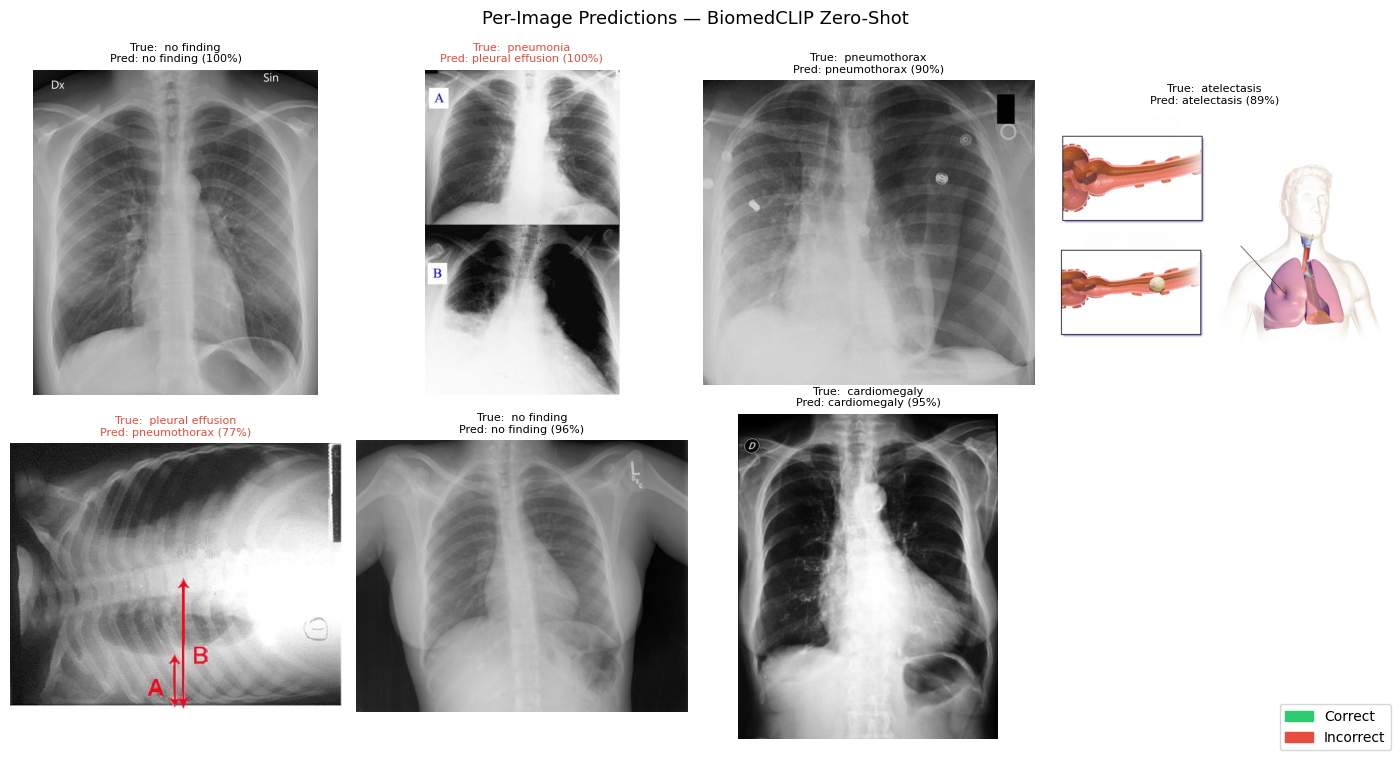

In [7]:
n = len(results)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.8))
axes = np.array(axes).flatten()

for i, r in enumerate(results):
    ax = axes[i]
    ax.imshow(r['image'], cmap='gray')
    color = '#2ecc71' if r['correct'] else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(
        f"True:  {r['true_label']}\nPred: {r['predicted_label']} ({r['top_score']:.0%})",
        fontsize=8, color=color if not r['correct'] else 'black'
    )
    ax.axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

correct_patch = mpatches.Patch(color='#2ecc71', label='Correct')
wrong_patch   = mpatches.Patch(color='#e74c3c', label='Incorrect')
fig.legend(handles=[correct_patch, wrong_patch], loc='lower right', fontsize=10)
plt.suptitle('Per-Image Predictions — BiomedCLIP Zero-Shot', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Confidence score distribution

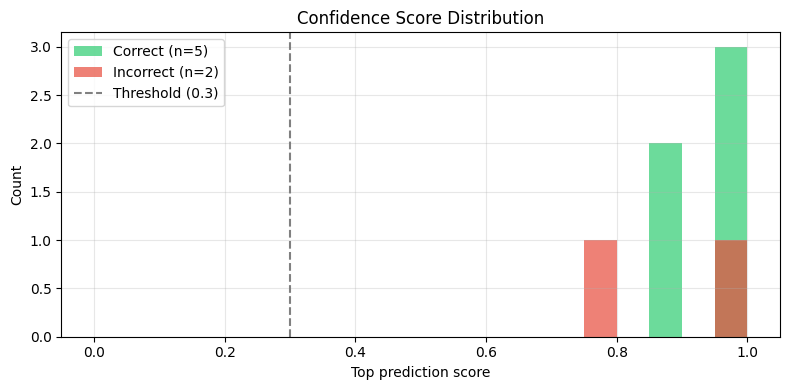

In [8]:
correct_scores   = [r['top_score'] for r in results if r['correct']]
incorrect_scores = [r['top_score'] for r in results if not r['correct']]

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
ax.hist(correct_scores,   bins=bins, alpha=0.7, color='#2ecc71', label=f'Correct (n={len(correct_scores)})')
ax.hist(incorrect_scores, bins=bins, alpha=0.7, color='#e74c3c', label=f'Incorrect (n={len(incorrect_scores)})')
ax.axvline(0.3, color='gray', linestyle='--', label='Threshold (0.3)')
ax.set_xlabel('Top prediction score')
ax.set_ylabel('Count')
ax.set_title('Confidence Score Distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Save results

In [9]:
import json, os

out_dir = Path('../evaluation/results')
out_dir.mkdir(parents=True, exist_ok=True)

serializable = [{k: v for k, v in r.items() if k != 'image'} for r in results]
with open(out_dir / 'results_notebook.json', 'w') as f:
    json.dump(serializable, f, indent=2)

with open(out_dir / 'report_notebook.txt', 'w') as f:
    f.write(format_report(metrics))

print(f'Saved to {out_dir}/')

Saved to ../evaluation/results/
